# Imports


In [ ]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

# Make the kernel robust if launched through VSCode/Jupyter rather than
# from an already activated conda shell.
CONDA_PREFIX = Path(sys.executable).resolve().parents[1]
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTHONNOUSERSITE"] = "1"

# Prefer the active conda environment libraries on Juno.
os.environ["LD_LIBRARY_PATH"] = (
    f"{CONDA_PREFIX / 'lib'}:" + os.environ.get("LD_LIBRARY_PATH", "")
)

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq
import cellcharter as cc
import scvi
import torch
import matplotlib.pyplot as plt

from lightning.pytorch import seed_everything
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
)
from scipy.optimize import linear_sum_assignment

try:
    from IPython.display import display
except Exception:
    display = print

# Keep numerical behavior reasonably reproducible on Ampere GPUs.
torch.set_float32_matmul_precision("high")

print("Python:", sys.executable)
print("CONDA_PREFIX:", CONDA_PREFIX)
print("cellcharter:", getattr(cc, "__version__", cc.__file__))
print("scvi:", scvi.__version__)
print("scanpy:", sc.__version__)
print("squidpy:", sq.__version__)
print("torch:", torch.__version__, "cuda:", torch.version.cuda, "available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("numpy:", np.__version__)
print("pandas:", pd.__version__)


ModuleNotFoundError: No module named 'lightning'

# USER CONFIGURATION — edit these to match your environment


In [ ]:
# =============================================================================
# USER CONFIGURATION
# =============================================================================

# Path to cloned CellCharter repo. This is not strictly required if the package
# was installed editable, but keeping it mirrors the attached INSTINCT/SpaCross format.
CELLCHARTER_ROOT = Path(r"/work/dal875013/projects/mocha/methods/cellcharter")

# Path to the folder containing SCE_151*.h5ad files
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")

# Output folder for donor-level multi-sample CellCharter benchmark
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter_multi")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METHOD_NAME = "CellCharter_multi"

# Donor-level DLPFC grouping:
# one donor/patient = four adjacent DLPFC slices.
DLPFC_DONOR_GROUPS = {
    "donor_1": ["151507", "151508", "151509", "151510"],
    "donor_2": ["151669", "151670", "151671", "151672"],
    "donor_3": ["151673", "151674", "151675", "151676"],
}

# ----- SUBSET SELECTOR -----------------------------------------------------
# First smoke test:
# DONOR_GROUPS_TO_RUN = "donor_3"
#
# After donor_3 works, set:
DONOR_GROUPS_TO_RUN = None

# Number of repeated runs per donor group.
NUM_RUNS = 1

# Fixed number of DLPFC cortical layer clusters.
# For the standard DLPFC benchmark we use K=7.
NUM_CLUSTERS_DLPFC = 7

# Which column in adata.obs holds the ground-truth layer labels.
# Leave as None to auto-detect from common names.
GT_LABEL_COL = "z"

# =============================================================================
# CellCharter/scVI settings
# =============================================================================

# CellCharter transcriptomics workflow:
# counts layer -> scVI -> X_scVI -> spatial graph -> aggregate_neighbors -> GMM Cluster.
COUNT_LAYER = "counts"
SCVI_LATENT_KEY = "X_scVI"
CELLCHARTER_KEY = "X_cellcharter"
CLUSTER_KEY = "spatial_cluster"

SCVI_N_LATENT = 10
SCVI_MAX_EPOCHS = None       # None lets scVI decide. For smoke test, try 50.
SCVI_EARLY_STOPPING = True
SCVI_BATCH_KEY = "sample"

# DLPFC has many genes, unlike the CosMx tutorial's ~960 genes.
# We therefore keep the official logic but add a benchmark adaptation:
# HVG selection before scVI, after saving raw counts.
USE_HVG = True
N_TOP_GENES = 2000

# Conservative filtering, matching the official CosMx preprocessing idea.
MIN_GENE_COUNTS = 3
MIN_CELL_COUNTS = 3

# CellCharter spatial graph + aggregation.
SPATIAL_KEY = "spatial"
SAMPLE_KEY = "sample"
N_LAYERS = 3
USE_DELAUNAY = True
SPATIAL_PERCENTILE = 99
REMOVE_LONG_LINKS = True

# CellCharter GMM clustering.
CELLCHARTER_CLUSTER_ON_GPU = True
CELLCHARTER_BATCH_SIZE = None    # Set e.g. 4096 if full-batch GMM uses too much memory.

# Output policy for benchmark files.
# This notebook only writes benchmark.log, performance.parquet, and predictions.parquet.

# Base seed. Each run uses BASE_SEED + run index.
BASE_SEED = 12345

# =============================================================================
# Helpers
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"

    # Avoid duplicated handlers when rerunning notebook cells.
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
        handlers=[
            logging.FileHandler(log_file, mode="w"),
            logging.StreamHandler(sys.stdout),
        ],
    )
    logging.info(f"[LOG] Writing log to {log_file.resolve()}")


def resolve_donor_groups(selector):
    """Resolve DONOR_GROUPS_TO_RUN into dict: donor_name -> sample_ids."""
    if selector is None or selector == "all":
        return dict(DLPFC_DONOR_GROUPS)
    if isinstance(selector, str):
        if selector not in DLPFC_DONOR_GROUPS:
            raise ValueError(f"Unknown donor group: {selector}")
        return {selector: DLPFC_DONOR_GROUPS[selector]}
    if isinstance(selector, (list, tuple)):
        unknown = sorted(set(selector) - set(DLPFC_DONOR_GROUPS))
        if unknown:
            raise ValueError(f"Unknown donor group(s): {unknown}")
        return {name: DLPFC_DONOR_GROUPS[name] for name in selector}
    raise ValueError(f"Unrecognized DONOR_GROUPS_TO_RUN value: {selector!r}")


def detect_gt_column(adata) -> str:
    """Auto-detect which obs column holds the ground-truth layer label."""
    if GT_LABEL_COL is not None:
        if GT_LABEL_COL not in adata.obs.columns:
            raise KeyError(
                f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
                f"Available columns: {list(adata.obs.columns)}"
            )
        return GT_LABEL_COL

    candidates = [
        "z",
        "Manual_Annotation", "ManualAnnotation",
        "layer_guess", "layer_guess_reordered", "layer_guess_reordered_short",
        "Ground Truth", "ground_truth", "GroundTruth",
        "layer", "Layer", "annotation", "Annotation",
    ]
    for c in candidates:
        if c in adata.obs.columns:
            return c

    raise KeyError(
        f"Could not auto-detect ground-truth column. "
        f"adata.obs columns: {list(adata.obs.columns)}. "
        f"Please set GT_LABEL_COL manually."
    )


def _copy_matrix(X):
    """Copy dense or sparse AnnData matrix without accidentally densifying."""
    return X.copy()


def get_device():
    """Return 'cuda:0' if available, else 'cpu'."""
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available — using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU detected — falling back to CPU")
    return dev


# Data loading  (adapted for .h5ad input)


In [ ]:
# =============================================================================
# Data loading  (adapted for .h5ad input)
# =============================================================================
def load_one_dlpfc_slice_for_cellcharter(sample_id: str):
    """
    Load one DLPFC .h5ad slice and convert it into the common benchmark format.

    This follows the data-loading style of the attached INSTINCT/SpaCross notebooks:
      - read SCE_<sample>.h5ad from DATA_ROOT
      - use obs['z'] as ground truth by default
      - alias obsm['S'] -> obsm['spatial'] if needed
      - preserve original spot IDs for later prediction parquet / visualization

    Returns:
        adata  : AnnData for one slice
        gt_col : original ground-truth obs column
    """
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"    [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"    [DIAG] {sample_id}: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"    [DIAG] {sample_id}: obs columns={list(adata.obs.columns)}")
    logging.info(f"    [DIAG] {sample_id}: obsm keys={list(adata.obsm.keys())}")

    # ---- Ground-truth label column ----
    gt_col = detect_gt_column(adata)
    adata.obs["layer_guess"] = adata.obs[gt_col].astype(object)
    adata.obs[SAMPLE_KEY] = sample_id
    adata.obs["original_spot_id"] = adata.obs_names.astype(str)

    n_labeled = int(adata.obs["layer_guess"].notna().sum())
    logging.info(
        f"    [DIAG] {sample_id}: using GT column '{gt_col}' "
        f"(labeled spots: {n_labeled}/{adata.n_obs})"
    )

    # ---- Spatial coordinates ----
    # Your DLPFC .h5ad usually stores spatial coordinates in obsm['S'].
    # CellCharter/Squidpy expects an explicit spatial key.
    if SPATIAL_KEY not in adata.obsm:
        if "S" in adata.obsm:
            adata.obsm[SPATIAL_KEY] = np.asarray(adata.obsm["S"])
            logging.info(f"    [DIAG] {sample_id}: aliased obsm['S'] -> obsm['{SPATIAL_KEY}']")
        else:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata.obsm.keys())}"
            )
    else:
        adata.obsm[SPATIAL_KEY] = np.asarray(adata.obsm[SPATIAL_KEY])

    logging.info(
        f"    [DIAG] {sample_id}: spatial coords shape={adata.obsm[SPATIAL_KEY].shape}"
    )

    # Make obs_names unique across slices, while preserving original_spot_id.
    adata.obs_names = [f"{x}_{sample_id}" for x in adata.obs_names.astype(str)]

    return adata, gt_col


def load_dlpfc_donor_group_for_cellcharter(donor_name: str, sample_ids: list):
    """
    Load 4 DLPFC slices for one donor group and concatenate them into one AnnData.

    This mirrors the official CellCharter CosMx multi-sample tutorial:
      list of AnnData per sample -> ad.concat(...) -> one AnnData with obs['sample'].

    The spatial graph later uses library_key/sample_key so edges are computed
    within each slice only, while scVI and CellCharter clustering are fit jointly
    across the four slices of the donor.

    Returns:
        adata_concat : concatenated AnnData
        gt_cols      : dict sample_id -> original GT column
    """
    logging.info(f"  [DONOR] Loading {donor_name}: {sample_ids}")

    adata_list = []
    gt_cols = {}

    for sample_id in sample_ids:
        adata, gt_col = load_one_dlpfc_slice_for_cellcharter(sample_id)
        adata_list.append(adata)
        gt_cols[sample_id] = gt_col

    # Use inner gene intersection to guarantee a shared feature space across slices.
    adata_concat = ad.concat(
        adata_list,
        axis=0,
        join="inner",
        merge="same",
        label="slice_name",
        keys=sample_ids,
        index_unique=None,
    )
    adata_concat.obs[SAMPLE_KEY] = pd.Categorical(adata_concat.obs[SAMPLE_KEY].astype(str))
    adata_concat.obs_names_make_unique()

    logging.info(
        f"  [DIAG] Combined {donor_name}: n_obs={adata_concat.n_obs}, "
        f"n_vars={adata_concat.n_vars}, slices={sample_ids}"
    )

    # -------------------------------------------------------------------------
    # Official CosMx preprocessing logic:
    #   filter genes/cells -> save counts layer -> normalize_total -> log1p
    # We add HVG selection because Visium has many genes.
    # -------------------------------------------------------------------------
    sc.pp.filter_genes(adata_concat, min_counts=MIN_GENE_COUNTS)
    sc.pp.filter_cells(adata_concat, min_counts=MIN_CELL_COUNTS)
    logging.info(
        f"  [DIAG] After basic filtering: n_obs={adata_concat.n_obs}, "
        f"n_vars={adata_concat.n_vars}"
    )

    # Save raw count matrix for scVI before normalization/log transform.
    adata_concat.layers[COUNT_LAYER] = _copy_matrix(adata_concat.X)

    # Normalize/log only for HVG selection and diagnostics. scVI uses counts layer.
    sc.pp.normalize_total(adata_concat, target_sum=1e6)
    sc.pp.log1p(adata_concat)

    if USE_HVG:
        n_top = min(N_TOP_GENES, adata_concat.n_vars)
        sc.pp.highly_variable_genes(
            adata_concat,
            n_top_genes=n_top,
            flavor="seurat",
        )
        n_hvg = int(adata_concat.var["highly_variable"].sum())
        logging.info(f"  [DIAG] HVGs selected: {n_hvg}/{adata_concat.n_vars}")
        adata_concat = adata_concat[:, adata_concat.var["highly_variable"]].copy()
        logging.info(f"  [DIAG] After HVG subset: n_vars={adata_concat.n_vars}")

    return adata_concat, gt_cols


# Metrics helpers


In [ ]:
# =============================================================================
# Metrics helpers
# =============================================================================
def clustering_accuracy(y_true, y_pred):
    """
    Clustering accuracy after optimal label matching via Hungarian algorithm.
    This is useful as a simple ACC column comparable across unsupervised runs.
    """
    y_true = pd.Series(y_true).astype(str).to_numpy()
    y_pred = pd.Series(y_pred).astype(str).to_numpy()

    true_classes = pd.Index(sorted(pd.unique(y_true)))
    pred_classes = pd.Index(sorted(pd.unique(y_pred)))

    contingency = np.zeros((len(true_classes), len(pred_classes)), dtype=np.int64)
    true_map = {c: i for i, c in enumerate(true_classes)}
    pred_map = {c: j for j, c in enumerate(pred_classes)}

    for t, p in zip(y_true, y_pred):
        contingency[true_map[t], pred_map[p]] += 1

    row_ind, col_ind = linear_sum_assignment(-contingency)
    return float(contingency[row_ind, col_ind].sum() / contingency.sum())


def compute_metrics_for_slice(adata_slice, label_key="layer_guess", pred_key=CLUSTER_KEY):
    """Compute metrics on labeled spots only for one slice."""
    labeled_mask = adata_slice.obs[label_key].notna()
    sub = adata_slice[labeled_mask].copy()

    if sub.n_obs == 0:
        return {
            "ARI": np.nan,
            "NMI": np.nan,
            "ACC": np.nan,
            "HOM": np.nan,
            "COM": np.nan,
            "V_measure": np.nan,
        }, sub

    y_true = sub.obs[label_key].astype(str).to_numpy()
    y_pred = sub.obs[pred_key].astype(str).to_numpy()

    metric_vals = {
        "ARI": float(adjusted_rand_score(y_true, y_pred)),
        "NMI": float(normalized_mutual_info_score(y_true, y_pred)),
        "ACC": float(clustering_accuracy(y_true, y_pred)),
        "HOM": float(homogeneity_score(y_true, y_pred)),
        "COM": float(completeness_score(y_true, y_pred)),
        "V_measure": float(v_measure_score(y_true, y_pred)),
    }
    return metric_vals, sub


# Donor-level CellCharter training


In [ ]:
# =============================================================================
# Train one donor group and return slice-level metrics
# =============================================================================
def train_one_donor_group(
    donor_name: str,
    sample_ids: list,
    adata,
    device: str,
    run_seed: int = 0,
):
    """
    Run CellCharter once on one donor group, then compute metrics separately
    for each slice.

    Method body follows the official CellCharter transcriptomics workflow:
        counts layer
        -> scVI latent representation with batch_key='sample'
        -> squidpy spatial_neighbors with library_key='sample'
        -> CellCharter remove_long_links
        -> CellCharter aggregate_neighbors
        -> CellCharter GMM Cluster with fixed K

    Important:
        The spatial graph is sample-specific because library_key/sample_key is used.
        The scVI representation and GMM clustering are donor-level joint models.
    """
    num_clusters = int(NUM_CLUSTERS_DLPFC)

    logging.info(
        f"  [TRAIN] Starting CellCharter donor-level | donor={donor_name} | "
        f"slices={sample_ids} | k_clusters={num_clusters} | "
        f"device={device} | run_seed={run_seed}"
    )

    seed = BASE_SEED + run_seed
    seed_everything(seed, workers=True)
    scvi.settings.seed = seed
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    t0 = time.time()

    # ---------------------------------------------------------------------
    # 1) scVI dimensionality reduction
    # ---------------------------------------------------------------------
    logging.info("  [SCVI] setup_anndata(layer='counts', batch_key='sample')")
    scvi.model.SCVI.setup_anndata(
        adata,
        layer=COUNT_LAYER,
        batch_key=SCVI_BATCH_KEY,
    )

    logging.info(
        f"  [SCVI] Training SCVI(n_latent={SCVI_N_LATENT}, "
        f"early_stopping={SCVI_EARLY_STOPPING})"
    )
    model = scvi.model.SCVI(
        adata,
        n_latent=SCVI_N_LATENT,
    )

    train_kwargs = dict(
        early_stopping=SCVI_EARLY_STOPPING,
        enable_progress_bar=True,
    )
    if SCVI_MAX_EPOCHS is not None:
        train_kwargs["max_epochs"] = SCVI_MAX_EPOCHS

    if torch.cuda.is_available():
        train_kwargs.update(dict(accelerator="gpu", devices=1))
    else:
        train_kwargs.update(dict(accelerator="cpu"))

    try:
        model.train(**train_kwargs)
    except TypeError:
        # Compatibility fallback for older/newer scvi-tools trainer signatures.
        logging.warning("  [SCVI] train_kwargs failed; retrying with minimal train()")
        model.train(
            max_epochs=SCVI_MAX_EPOCHS,
            early_stopping=SCVI_EARLY_STOPPING,
            enable_progress_bar=True,
        )

    adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation(adata).astype(np.float32)
    logging.info(f"  [DIAG] {SCVI_LATENT_KEY} shape: {adata.obsm[SCVI_LATENT_KEY].shape}")

    # ---------------------------------------------------------------------
    # 2) Spatial graph, following CellCharter tutorials
    # ---------------------------------------------------------------------
    logging.info("  [GRAPH] squidpy.gr.spatial_neighbors(library_key='sample')")
    sq.gr.spatial_neighbors(
        adata,
        library_key=SAMPLE_KEY,
        coord_type="generic",
        delaunay=USE_DELAUNAY,
        spatial_key=SPATIAL_KEY,
        percentile=SPATIAL_PERCENTILE,
    )

    if REMOVE_LONG_LINKS:
        logging.info("  [GRAPH] cellcharter.gr.remove_long_links")
        try:
            cc.gr.remove_long_links(adata)
        except Exception as e:
            logging.warning(f"  [GRAPH] remove_long_links failed; continuing. Error: {e}")

    # ---------------------------------------------------------------------
    # 3) CellCharter neighborhood aggregation
    # ---------------------------------------------------------------------
    logging.info(
        f"  [CC] aggregate_neighbors(n_layers={N_LAYERS}, use_rep={SCVI_LATENT_KEY})"
    )
    cc.gr.aggregate_neighbors(
        adata,
        n_layers=N_LAYERS,
        use_rep=SCVI_LATENT_KEY,
        out_key=CELLCHARTER_KEY,
        sample_key=SAMPLE_KEY,
    )
    logging.info(f"  [DIAG] {CELLCHARTER_KEY} shape: {adata.obsm[CELLCHARTER_KEY].shape}")

    # ---------------------------------------------------------------------
    # 4) CellCharter GMM clustering
    # ---------------------------------------------------------------------
    if CELLCHARTER_CLUSTER_ON_GPU and torch.cuda.is_available():
        trainer_params = dict(accelerator="gpu", devices=1, enable_progress_bar=True)
    else:
        trainer_params = dict(accelerator="cpu", enable_progress_bar=True)

    logging.info("  [CC] Fitting CellCharter Cluster on donor-level X_cellcharter")
    gmm = cc.tl.Cluster(
        n_clusters=num_clusters,
        random_state=seed,
        batch_size=CELLCHARTER_BATCH_SIZE,
        trainer_params=trainer_params,
    )
    gmm.fit(adata, use_rep=CELLCHARTER_KEY)
    pred_labels = gmm.predict(adata, use_rep=CELLCHARTER_KEY)

    adata.obs[CLUSTER_KEY] = pd.Categorical(
        pd.Series(pred_labels, index=adata.obs_names).astype(str)
    )

    logging.info(
        f"  [DIAG] {donor_name}: cluster sizes="
        f"{adata.obs[CLUSTER_KEY].astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics_list = []
    pred_frames = []

    # ---------------------------------------------------------------------
    # 5) Slice-level metrics and predictions
    # ---------------------------------------------------------------------
    for sample_id in sample_ids:
        mask = adata.obs[SAMPLE_KEY].astype(str).to_numpy() == str(sample_id)
        slice_adata = adata[mask].copy()

        metric_vals, labeled_slice = compute_metrics_for_slice(
            slice_adata,
            label_key="layer_guess",
            pred_key=CLUSTER_KEY,
        )

        metrics = {
            "method": METHOD_NAME,
            "sample": sample_id,
            "training_unit": donor_name,
            "training_samples": ",".join(sample_ids),
            "run_seed": run_seed,
            **metric_vals,
            # Keep DIS column for compatibility with older SpaCross-style summaries.
            "DIS": np.nan,
            # Allocate donor-level runtime across slices for table compatibility.
            "running_time_sec": round(elapsed / max(1, len(sample_ids)), 2),
            "donor_running_time_sec": round(elapsed, 2),
            "unit_running_time_sec": round(elapsed, 2),
            "gpu_model": gpu_name,
            "num_clusters": int(num_clusters),
            "num_spots": int(slice_adata.n_obs),
            "num_labeled_spots": int(labeled_slice.n_obs),
            "num_training_spots": int(adata.n_obs),
            "num_genes_after_hvg": int(adata.n_vars),
            "scvi_n_latent": int(SCVI_N_LATENT),
            "cellcharter_dim": int(adata.obsm[CELLCHARTER_KEY].shape[1]),
            "n_layers": int(N_LAYERS),
            "cluster_key": CLUSTER_KEY,
            "device": device,
        }
        metrics_list.append(metrics)

        logging.info(
            f"  [METRICS] {donor_name}/{sample_id}: "
            f"ARI={metric_vals['ARI']:.4f}  NMI={metric_vals['NMI']:.4f}  "
            f"ACC={metric_vals['ACC']:.4f}  "
            f"allocated_time={elapsed / len(sample_ids):.1f}s  "
            f"donor_time={elapsed:.1f}s  gpu={gpu_name}"
        )

        spot_ids = (
            slice_adata.obs["original_spot_id"].astype(str).to_numpy()
            if "original_spot_id" in slice_adata.obs.columns
            else slice_adata.obs_names.astype(str).to_numpy()
        )

        pred_frames.append(
            pd.DataFrame(
                {
                    "method": METHOD_NAME,
                    "sample": sample_id,
                    "training_unit": donor_name,
                    "run_seed": run_seed,
                    "spot_id": spot_ids,
                    "true_label": slice_adata.obs["layer_guess"].astype(object).to_numpy(),
                    "pred_label": slice_adata.obs[CLUSTER_KEY].astype(str).to_numpy(),
                }
            )
        )

    pred_df = pd.concat(pred_frames, ignore_index=True)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics_list, pred_df


# Main benchmark loop


In [ ]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("CellCharter DLPFC Donor-Level Multi-Sample Benchmarking Framework")
    logging.info("=" * 72)

    # Optional local repo sanity check.
    if CELLCHARTER_ROOT.exists():
        logging.info(f"[PATHS] CELLCHARTER_ROOT = {CELLCHARTER_ROOT.resolve()}")
        if str(CELLCHARTER_ROOT.resolve()) not in sys.path:
            sys.path.insert(0, str(CELLCHARTER_ROOT.resolve()))
    else:
        logging.warning(f"[PATHS] CELLCHARTER_ROOT not found: {CELLCHARTER_ROOT}")

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    device = get_device()

    logging.info(f"[PATHS] DATA_ROOT  = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR = {OUTPUT_DIR.resolve()}")
    logging.info("[OUTPUT] Writing only benchmark.log, performance.parquet, predictions.parquet")
    logging.info(f"[ENV] Python       = {sys.executable}")
    logging.info(f"[VERSIONS] cellcharter = {getattr(cc, '__version__', cc.__file__)}")
    logging.info(f"[VERSIONS] scvi        = {scvi.__version__}")
    logging.info(f"[VERSIONS] scanpy      = {sc.__version__}")
    logging.info(f"[VERSIONS] squidpy     = {sq.__version__}")
    logging.info(f"[VERSIONS] torch       = {torch.__version__}")

    donor_groups = resolve_donor_groups(DONOR_GROUPS_TO_RUN)
    logging.info(f"[DONORS] Will process {len(donor_groups)} donor group(s): {donor_groups}")
    logging.info(
        f"[SETTINGS] NUM_RUNS={NUM_RUNS} | K={NUM_CLUSTERS_DLPFC} | "
        f"SCVI_N_LATENT={SCVI_N_LATENT} | N_LAYERS={N_LAYERS} | USE_HVG={USE_HVG}"
    )
    logging.info("[MODE] donor-level joint CellCharter training; slice-level metrics/output")

    all_metrics = []
    all_predictions = []
    failed = []

    for i, (donor_name, sample_ids) in enumerate(donor_groups.items(), start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(donor_groups)}] Donor group {donor_name}: {sample_ids}")
        logging.info("-" * 72)

        try:
            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")

                # Reload the data for each run because scVI/CellCharter modifies AnnData.
                adata, gt_cols = load_dlpfc_donor_group_for_cellcharter(
                    donor_name=donor_name,
                    sample_ids=sample_ids,
                )

                metrics_list, pred_df = train_one_donor_group(
                    donor_name=donor_name,
                    sample_ids=sample_ids,
                    adata=adata,
                    device=device,
                    run_seed=run,
                )

                for row in metrics_list:
                    row["gt_col"] = gt_cols.get(row["sample"], GT_LABEL_COL)
                all_metrics.extend(metrics_list)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Donor group {donor_name}: {e}")
            failed.append({"training_unit": donor_name, "error": str(e)})
            continue

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    if not all_metrics:
        logging.error("No successful runs — nothing to save.")
        if failed:
            logging.error(f"Failed donor group details: {failed}")
        return pd.DataFrame(), pd.DataFrame(), failed

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "training_unit", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS", "HOM", "COM", "V_measure",
        "running_time_sec", "donor_running_time_sec", "unit_running_time_sec",
        "gpu_model", "training_samples",
    ]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    pred_lead = ["method", "training_unit", "sample", "run_seed", "spot_id", "true_label", "pred_label"]
    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"
    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)


    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)
    logging.info(f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)")
    logging.info(f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)")

    logging.info("")
    logging.info("Per-slice metrics:")
    show_cols = [
        "training_unit", "sample", "ARI", "NMI", "ACC",
        "HOM", "COM", "V_measure",
        "running_time_sec", "donor_running_time_sec",
    ]
    show_cols = [c for c in show_cols if c in performance.columns]
    logging.info("\n" + performance[show_cols].to_string(index=False))

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}"
    )
    logging.info(f"GPU model(s) used: {sorted(performance['gpu_model'].unique().tolist())}")
    logging.info(
        "Total donor-level running time: "
        f"{performance[['training_unit', 'run_seed', 'donor_running_time_sec']].drop_duplicates()['donor_running_time_sec'].sum():.1f}s"
    )

    if failed:
        logging.warning(f"{len(failed)} donor group(s) failed. Details recorded in benchmark.log only: {failed}")
    else:
        logging.info("[DONE] All requested donor groups completed successfully.")

    return performance, predictions, failed


# Execute the benchmark when this cell is run.
performance, predictions, failed = run_benchmark()


2026-05-18 03:02:36,984 | INFO | [LOG] Writing log to /work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter_multi/benchmark.log
2026-05-18 03:02:36,986 | INFO | ========================================================================
2026-05-18 03:02:36,986 | INFO | CellCharter DLPFC Donor-Level Multi-Sample Benchmarking Framework
2026-05-18 03:02:36,987 | INFO | ========================================================================
2026-05-18 03:02:36,989 | INFO | [PATHS] CELLCHARTER_ROOT = /work/dal875013/projects/mocha/methods/cellcharter
2026-05-18 03:02:36,992 | INFO | [DEVICE] CUDA available — using cuda:0
2026-05-18 03:02:36,993 | INFO | [DEVICE] GPU name: NVIDIA A30
2026-05-18 03:02:36,993 | INFO | [DEVICE] GPU memory: 25.22 GB
2026-05-18 03:02:36,995 | INFO | [PATHS] DATA_ROOT  = /groups/qiwei/mocha/QuickSRT/DLPFC_10x/data
2026-05-18 03:02:36,996 | INFO | [PATHS] OUTPUT_DIR = /work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter_multi
2026-05-18

[rank: 0] Seed set to 12345
[rank: 0] Seed set to 12345


2026-05-18 03:02:40,481 | INFO |   [SCVI] setup_anndata(layer='counts', batch_key='sample')
2026-05-18 03:02:40,484 | INFO |   [SCVI] Training SCVI(n_latent=10, early_stopping=True)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 400/400: 100%|██████████| 400/400 [05:28<00:00,  1.55s/it, v_num=1, train_loss=290]

...

100%|██████████| 4/4 [00:00<00:00, 24.63it/s]

2026-05-18 03:19:14,822 | INFO |   [DIAG] X_cellcharter shape: (14364, 40)
2026-05-18 03:19:14,822 | INFO |   [CC] Fitting CellCharter Cluster on donor-level X_cellcharter



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


2026-05-18 03:19:16,795 | INFO |   [DIAG] donor_3: cluster sizes={'0': 2561, '2': 2323, '4': 2321, '3': 2107, '1': 2032, '5': 1752, '6': 1268}
2026-05-18 03:19:16,848 | INFO |   [METRICS] donor_3/151673: ARI=0.2966  NMI=0.4647  ACC=0.4672  allocated_time=96.4s  donor_time=385.5s  gpu=NVIDIA A30
2026-05-18 03:19:16,898 | INFO |   [METRICS] donor_3/151674: ARI=0.3274  NMI=0.4798  ACC=0.4960  allocated_time=96.4s  donor_time=385.5s  gpu=NVIDIA A30
2026-05-18 03:19:16,943 | INFO |   [METRICS] donor_3/151675: ARI=0.3416  NMI=0.4974  ACC=0.4874  allocated_time=96.4s  donor_time=385.5s  gpu=NVIDIA A30
2026-05-18 03:19:16,989 | INFO |   [METRICS] donor_3/151676: ARI=0.2994  NMI=0.4669  ACC=0.4640  allocated_time=96.4s  donor_time=385.5s  gpu=NVIDIA A30
2026-05-18 03:19:17,063 | INFO | 
2026-05-18 03:19:17,064 | INFO | ========================================================================
2026-05-18 03:19:17,065 | INFO | SAVED
2026-05-18 03:19:17,065 | INFO | =================================

# Donor-level 4-slice visualization


... storing 'true_label' as categorical
... storing 'pred_label' as categorical
... storing 'true_label' as categorical
... storing 'pred_label' as categorical
... storing 'true_label' as categorical
... storing 'pred_label' as categorical
... storing 'true_label' as categorical
... storing 'pred_label' as categorical


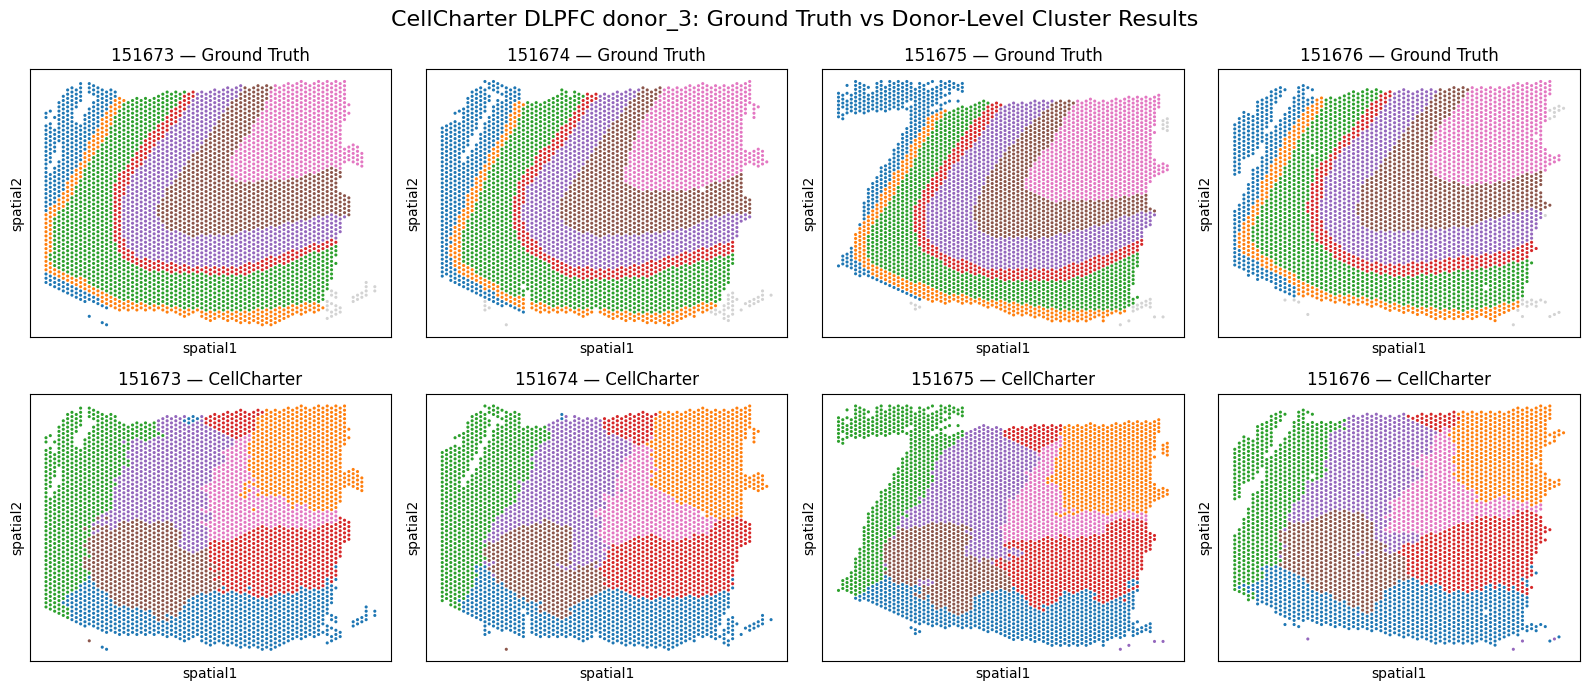

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter_multi")

DONOR_TO_PLOT = "donor_3"
SAMPLES_TO_PLOT = {
    "donor_1": ["151507", "151508", "151509", "151510"],
    "donor_2": ["151669", "151670", "151671", "151672"],
    "donor_3": ["151673", "151674", "151675", "151676"],
}[DONOR_TO_PLOT]

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

fig, axes = plt.subplots(2, len(SAMPLES_TO_PLOT), figsize=(4 * len(SAMPLES_TO_PLOT), 7))
fig.suptitle(f"CellCharter DLPFC {DONOR_TO_PLOT}: Ground Truth vs Donor-Level Cluster Results", fontsize=16)

for j, sample_id in enumerate(SAMPLES_TO_PLOT):
    pred_slice = predictions[predictions["sample"] == sample_id].set_index("spot_id")
    adata = sc.read_h5ad(DATA_ROOT / f"SCE_{sample_id}.h5ad")

    adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
    adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

    if "spatial" not in adata.obsm and "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])

    sc.pl.embedding(
        adata, basis="spatial", color="true_label",
        ax=axes[0, j], show=False, title=f"{sample_id} — Ground Truth", s=20,
        legend_loc=None,
    )
    sc.pl.embedding(
        adata, basis="spatial", color="pred_label",
        ax=axes[1, j], show=False, title=f"{sample_id} — CellCharter", s=20,
        legend_loc=None,
    )
    axes[0, j].invert_yaxis()
    axes[1, j].invert_yaxis()

plt.tight_layout()
plt.show()


# Running results summary


In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter_multi")
perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)
performance = performance.sort_values(["training_unit", "sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "training_unit", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS", "HOM", "COM", "V_measure",
    "num_clusters", "num_spots", "num_labeled_spots",
    "num_training_spots", "num_genes_after_hvg",
    "scvi_n_latent", "cellcharter_dim", "n_layers",
    "running_time_sec", "donor_running_time_sec",
    "gpu_model",
]
display_cols = [c for c in display_cols if c in performance.columns]

print("===== All CellCharter donor-level DLPFC results =====")
display(performance[display_cols])

print("\n===== Summary =====")
metric_cols = [c for c in ["ARI", "NMI", "ACC", "DIS", "HOM", "COM", "V_measure", "running_time_sec"] if c in performance.columns]
display(performance[metric_cols].describe())

print("\n===== Mean metrics =====")
for col in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure"]:
    if col in performance.columns:
        print(f"Mean {col}: {performance[col].mean():.4f}")

print("\n===== Donor-level runtime =====")
runtime = performance[["training_unit", "run_seed", "donor_running_time_sec"]].drop_duplicates()
display(runtime)
print(f"Total donor-level runtime: {runtime['donor_running_time_sec'].sum():.2f} sec")

print("\n===== Best / worst ARI =====")
if "ARI" in performance.columns and len(performance) > 0:
    best = performance.loc[performance["ARI"].idxmax()]
    worst = performance.loc[performance["ARI"].idxmin()]
    print(f"Best ARI : {best['sample']} ({best['training_unit']})  ARI={best['ARI']:.4f}")
    print(f"Worst ARI: {worst['sample']} ({worst['training_unit']})  ARI={worst['ARI']:.4f}")


===== All CellCharter donor-level DLPFC results =====


,training_unit,sample,run_seed,ARI,NMI,ACC,DIS,HOM,COM,V_measure,...,num_spots,num_labeled_spots,num_training_spots,num_genes_after_hvg,scvi_n_latent,cellcharter_dim,n_layers,running_time_sec,donor_running_time_sec,gpu_model
0,donor_1,151507,0,0.401766,0.503626,0.539209,NaN,0.514823,0.492906,0.503626,...,4226,4221,18033,2000,10,40,3,84.96,339.84,NVIDIA A30
1,donor_1,151508,0,0.420674,0.519517,0.532299,NaN,0.540391,0.500195,0.519517,...,4384,4381,18033,2000,10,40,3,84.96,339.84,NVIDIA A30
2,donor_1,151509,0,0.360161,0.502206,0.479532,NaN,0.546043,0.464884,0.502206,...,4789,4788,18033,2000,10,40,3,84.96,339.84,NVIDIA A30
3,donor_1,151510,0,0.333455,0.469271,0.455930,NaN,0.510398,0.434278,0.469271,...,4634,4595,18033,2000,10,40,3,84.96,339.84,NVIDIA A30
4,donor_2,151669,0,0.249508,0.457068,0.455171,NaN,0.576844,0.378480,0.457068,...,3661,3636,15284,2000,10,40,3,65.26,261.06,NVIDIA A30
5,donor_2,151670,0,0.237766,0.434815,0.462974,NaN,0.569746,0.351557,0.434815,...,3498,3484,15284,2000,10,40,3,65.26,261.06,NVIDIA A30
6,donor_2,151671,0,0.298456,0.498040,0.495969,NaN,0.594774,0.428370,0.498040,...,4110,4093,15284,2000,10,40,3,65.26,261.06,NVIDIA A30
7,donor_2,151672,0,0.355056,0.501069,0.529578,NaN,0.581357,0.440266,0.501069,...,4015,3888,15284,2000,10,40,3,65.26,261.06,NVIDIA A30
8,donor_3,151673,0,0.296565,0.464719,0.467184,NaN,0.479357,0.450949,0.464719,...,3639,3611,14364,2000,10,40,3,96.37,385.50,NVIDIA A30
9,donor_3,151674,0,0.327427,0.479819,0.496011,NaN,0.490068,0.469989,0.479819,...,3673,3635,14364,2000,10,40,3,96.37,385.50,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,HOM,COM,V_measure,running_time_sec
count,12.000000,12.000000,12.000000,0.0,12.000000,12.000000,12.000000,12.000000
mean,0.326826,0.482879,0.488770,NaN,0.532138,0.446620,0.482879,82.196667
std,0.054752,0.024631,0.030522,NaN,0.041729,0.044835,0.024631,13.421422
min,0.237766,0.434815,0.455171,NaN,0.476625,0.351557,0.434815,65.260000
25%,0.297983,0.466390,0.463747,NaN,0.501436,0.432801,0.466390,65.260000
50%,0.330441,0.488633,0.483456,NaN,0.527607,0.454301,0.488633,84.960000
75%,0.356333,0.501353,0.504403,NaN,0.571521,0.474968,0.501353,96.370000
max,0.420674,0.519517,0.539209,NaN,0.594774,0.500195,0.519517,96.370000



===== Mean metrics =====
Mean ARI: 0.3268
Mean NMI: 0.4829
Mean ACC: 0.4888
Mean HOM: 0.5321
Mean COM: 0.4466
Mean V_measure: 0.4829

===== Donor-level runtime =====


,training_unit,run_seed,donor_running_time_sec
0,donor_1,0,339.84
4,donor_2,0,261.06
8,donor_3,0,385.50


Total donor-level runtime: 986.40 sec

===== Best / worst ARI =====
Best ARI : 151508 (donor_1)  ARI=0.4207
Worst ARI: 151670 (donor_2)  ARI=0.2378


# Compare single-sample vs donor-level results


In [ ]:
import pandas as pd
from pathlib import Path

SINGLE_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter_single")
MULTI_DIR  = Path(r"/work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter_multi")

single_path = SINGLE_DIR / "performance.parquet"
multi_path = MULTI_DIR / "performance.parquet"

if not single_path.exists():
    print(f"[SKIP] Cannot find single-sample results: {single_path}")
elif not multi_path.exists():
    print(f"[SKIP] Cannot find donor-level results: {multi_path}")
else:
    single = pd.read_parquet(single_path).copy()
    multi = pd.read_parquet(multi_path).copy()

    single["setting"] = "single_sample"
    multi["setting"] = "donor_level"

    cols = ["setting", "training_unit", "sample", "run_seed", "ARI", "NMI", "ACC", "HOM", "COM", "V_measure", "running_time_sec"]
    cols = [c for c in cols if c in single.columns or c in multi.columns]

    combined = pd.concat([single, multi], ignore_index=True, sort=False)
    display(combined[cols].sort_values(["sample", "setting"]).reset_index(drop=True))

    print("\n===== Mean by setting =====")
    metric_cols = [c for c in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure", "running_time_sec"] if c in combined.columns]
    display(combined.groupby("setting")[metric_cols].mean())

    print("\n===== Per-sample donor-level minus single-sample =====")
    s = single.set_index(["sample", "run_seed"])
    m = multi.set_index(["sample", "run_seed"])
    delta = pd.DataFrame(index=m.index)
    for col in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure"]:
        if col in s.columns and col in m.columns:
            delta[f"delta_{col}"] = m[col] - s[col]
    display(delta.reset_index().sort_values(["sample", "run_seed"]))


[SKIP] Cannot find single-sample results: /work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter_single/performance.parquet
